# ==================================
# 1. データ読み込み
# ==================================

In [3]:
from google.cloud import bigquery
import pandas as pd

In [4]:
from google.cloud import bigquery

client = bigquery.Client(project="seikabutu-497407")

In [5]:
query = """
SELECT *
FROM mart_olist.mart_order_review
"""

df = client.query(query).to_dataframe()

df.head()

/home/kotaro/seikabutu/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_id,review_score,order_status,order_delivered_customer_date,order_estimated_delivery_date,order_purchase_timestamp,customer_state,item_count,total_price,total_freight,payment_type,total_payment,main_category,delivery_days,delay_days
0,c8c528189310eaa44a745b8d9d26908b,1,canceled,NaT,2018-09-11 00:00:00+00:00,2018-08-28 20:05:14+00:00,SP,<NA>,NaN,NaN,not_defined,0.00,NaN,<NA>,<NA>
1,4637ca194b6387e2d538dc89b124b0ee,3,canceled,NaT,2018-09-10 00:00:00+00:00,2018-09-03 14:14:25+00:00,SP,<NA>,NaN,NaN,not_defined,0.00,NaN,<NA>,<NA>
2,00b1cb0320190ca0daa2c88b35206009,1,canceled,NaT,2018-09-12 00:00:00+00:00,2018-08-28 15:26:39+00:00,SP,<NA>,NaN,NaN,not_defined,0.00,NaN,<NA>,<NA>
3,baec85e7fa005a17b89b8bf93300cb5f,1,unavailable,NaT,2018-01-31 00:00:00+00:00,2018-01-12 02:07:28+00:00,SP,<NA>,NaN,NaN,voucher,16.95,NaN,<NA>,<NA>
4,7622da48f027d5659a0d7b0a43597354,1,unavailable,NaT,2017-07-21 00:00:00+00:00,2017-07-09 14:27:44+00:00,SP,<NA>,NaN,NaN,credit_card,16.97,NaN,<NA>,<NA>



# ==================================
# 2. データ概要
# ==================================

### データ概要確認

分析対象テーブルの件数・カラム数を確認する。

In [6]:
df.shape

(99441, 15)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype              
---  ------                         --------------  -----              
 0   order_id                       99441 non-null  str                
 1   review_score                   98673 non-null  Int64              
 2   order_status                   99441 non-null  str                
 3   order_delivered_customer_date  96476 non-null  datetime64[us, UTC]
 4   order_estimated_delivery_date  99441 non-null  datetime64[us, UTC]
 5   order_purchase_timestamp       99441 non-null  datetime64[us, UTC]
 6   customer_state                 99441 non-null  str                
 7   item_count                     98666 non-null  Int64              
 8   total_price                    98666 non-null  float64            
 9   total_freight                  98666 non-null  float64            
 10  payment_type                   99

### 各reviewの割合を確認

In [25]:
df["review_score"].value_counts().sort_index(ascending = False)

review_score
5    57008
4    19038
3     8133
2     3131
1    11363
Name: count, dtype: Int64

In [27]:
df["review_score"].value_counts(normalize=True).sort_index(ascending = False)

review_score
5    0.577747
4     0.19294
3    0.082424
2    0.031731
1    0.115158
Name: proportion, dtype: Float64

### order_statusの分布を確認

In [21]:
df["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

### 支払方法とレビューの関係

In [28]:
df.groupby("payment_type")["review_score"].mean().sort_values()

payment_type
not_defined    1.666667
voucher        4.004806
boleto         4.086627
credit_card    4.088196
debit_card     4.168968
Name: review_score, dtype: Float64

In [29]:
df[df["payment_type"]=="not_defined"].head()

,order_id,review_score,order_status,order_delivered_customer_date,order_estimated_delivery_date,order_purchase_timestamp,customer_state,item_count,total_price,total_freight,payment_type,total_payment,main_category,delivery_days,delay_days
0,c8c528189310eaa44a745b8d9d26908b,1,canceled,NaT,2018-09-11 00:00:00+00:00,2018-08-28 20:05:14+00:00,SP,<NA>,NaN,NaN,not_defined,0.0,NaN,<NA>,<NA>
1,4637ca194b6387e2d538dc89b124b0ee,3,canceled,NaT,2018-09-10 00:00:00+00:00,2018-09-03 14:14:25+00:00,SP,<NA>,NaN,NaN,not_defined,0.0,NaN,<NA>,<NA>
2,00b1cb0320190ca0daa2c88b35206009,1,canceled,NaT,2018-09-12 00:00:00+00:00,2018-08-28 15:26:39+00:00,SP,<NA>,NaN,NaN,not_defined,0.0,NaN,<NA>,<NA>


### レビューにおける地域差の確認

In [31]:
df.groupby("customer_state")["review_score"].mean().sort_values(ascending = False)

customer_state
AM    4.205479
AP     4.19403
PR    4.181311
SP    4.173298
MG    4.135364
RS     4.13228
MS    4.110799
RN     4.10625
MT    4.101111
TO    4.096774
SC    4.073982
DF     4.06391
RO    4.051587
AC    4.049383
GO    4.044843
ES    4.037388
PB    4.016981
PE    4.008563
PI    3.918367
RJ    3.877434
BA    3.861677
CE    3.856712
PA    3.850312
SE    3.808023
MA    3.757412
AL    3.756098
RR    3.608696
Name: review_score, dtype: Float64

### レビューにおける商品カテゴリーでの差の確認

In [33]:
df.groupby("main_category")["review_score"].mean().sort_values(ascending = False)

main_category
cds_dvds_musicais                                4.666667
la_cuisine                                       4.545455
flores                                           4.538462
livros_interesse_geral                           4.468379
construcao_ferramentas_ferramentas               4.425532
                                                   ...   
fashion_roupa_masculina                          3.727273
moveis_escritorio                                3.631285
pc_gamer                                         3.428571
portateis_cozinha_e_preparadores_de_alimentos    3.428571
seguros_e_servicos                                    2.5
Name: review_score, Length: 73, dtype: Float64

In [34]:
df["main_category"].value_counts()

main_category
cama_mesa_banho                  9369
beleza_saude                     8823
esporte_lazer                    7679
informatica_acessorios           6659
moveis_decoracao                 6321
                                 ... 
cds_dvds_musicais                  12
la_cuisine                         11
pc_gamer                            7
fashion_roupa_infanto_juvenil       6
seguros_e_servicos                  2
Name: count, Length: 73, dtype: int64

# ==================================
# 3. 欠損確認
# ==================================

### 欠損値確認
各欠損値について、欠損率や欠損理由を調査する。

### 全体の欠損値の確認

In [9]:
df.isnull().sum()

order_id                            0
review_score                      768
order_status                        0
order_delivered_customer_date    2965
order_estimated_delivery_date       0
order_purchase_timestamp            0
customer_state                      0
item_count                        775
total_price                       775
total_freight                     775
payment_type                        1
total_payment                       1
main_category                    2213
delivery_days                    2965
delay_days                       2965
dtype: int64

### 欠損レコードの注文状態を確認

In [14]:
df[df["item_count"].isna()]["order_status"].value_counts()

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

### main_categoryの欠損率を確認

In [15]:
df["main_category"].isna().mean()

np.float64(0.022254402107782505)

### reviewの欠損値の数を確認

In [17]:
df["review_score"].isnull().sum()

np.int64(768)

In [18]:
df["review_score"].isnull().mean()

np.float64(0.0077231725344676745)

# ==================================
# 4. 配送関連確認
# ==================================

### 配送遅延日数ごとのレビュー平均値

In [35]:
df.groupby("delay_days")["review_score"].mean()

delay_days
0      4.290247
1      3.731707
2      3.179104
3      2.683468
4      2.497706
         ...   
166         1.0
167         1.0
175         1.0
181        <NA>
188         2.0
Name: review_score, Length: 116, dtype: Float64

### 配送遅延日数の分布確認

In [37]:
df.groupby("delay_days").size()

delay_days
0      89941
1        825
2        545
3        500
4        453
       ...  
166        1
167        1
175        1
181        1
188        1
Length: 116, dtype: int64

### 目的変数であるreview_scoreが欠損しているものは分析対象から除外。また配送状態についても配送が完了していないものは除外。

In [43]:
df_analysis =df[df["order_status"]=="delivered"].dropna(subset=["review_score"])
df_analysis

,order_id,review_score,order_status,order_delivered_customer_date,order_estimated_delivery_date,order_purchase_timestamp,customer_state,item_count,total_price,total_freight,payment_type,total_payment,main_category,delivery_days,delay_days
775,6e864b3f0ec71031117ad4cf46b7f2a1,5,delivered,2018-05-04 19:32:53+00:00,2018-05-18 00:00:00+00:00,2018-04-24 20:15:21+00:00,RJ,1,0.85,18.23,credit_card,19.08,construcao_ferramentas_construcao,9,0
776,3ee6513ae7ea23bdfab5b9ab60bffcb5,4,delivered,2018-05-07 23:21:11+00:00,2018-05-17 00:00:00+00:00,2018-04-24 11:01:06+00:00,SP,1,0.85,18.23,boleto,19.08,construcao_ferramentas_construcao,13,0
777,f1d5c2e6867fa93ceee9ef9b34a53cbf,5,delivered,2018-08-29 18:19:41+00:00,2018-09-03 00:00:00+00:00,2018-08-25 21:20:50+00:00,SP,1,2.20,7.39,voucher,9.59,beleza_saude,3,0
778,e8bbc1d69fee39eee4c72cb5c969e39d,5,delivered,2017-09-18 18:42:07+00:00,2017-09-26 00:00:00+00:00,2017-09-13 19:13:20+00:00,SP,1,2.29,7.78,credit_card,10.07,papelaria,4,0
779,38bcb524e1c38c2c1b60600a80fc8999,5,delivered,2017-01-16 16:05:22+00:00,2017-02-13 00:00:00+00:00,2017-01-05 12:06:36+00:00,PR,1,2.90,8.72,boleto,11.62,pet_shop,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99435,2cc9089445046817a7539d90805e6e5a,1,delivered,2017-12-13 12:16:02+00:00,2017-12-22 00:00:00+00:00,2017-11-24 11:03:35+00:00,MG,6,5934.60,146.94,boleto,6081.54,agro_industria_e_comercio,19,0
99436,f5136e38d1a14a4dbd87dff67da82701,5,delivered,2017-06-05 17:09:48+00:00,2017-06-28 00:00:00+00:00,2017-05-24 18:14:34+00:00,SP,1,6499.00,227.66,boleto,6726.66,artes,11,0
99438,0812eb902a67711a1cb742b3cdaa65ae,5,delivered,2017-03-03 14:23:18+00:00,2017-03-09 00:00:00+00:00,2017-02-12 20:37:36+00:00,MS,1,6735.00,194.31,credit_card,6929.31,utilidades_domesticas,18,0
99439,736e1922ae60d0d6a89247b851902527,1,delivered,2018-07-26 22:03:06+00:00,2018-08-02 00:00:00+00:00,2018-07-15 14:49:44+00:00,ES,4,7160.00,114.88,boleto,7274.88,telefonia_fixa,11,0


In [44]:
df_analysis.shape

(95832, 15)

In [45]:
df_analysis.info()

<class 'pandas.DataFrame'>
Index: 95832 entries, 775 to 99440
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype              
---  ------                         --------------  -----              
 0   order_id                       95832 non-null  str                
 1   review_score                   95832 non-null  Int64              
 2   order_status                   95832 non-null  str                
 3   order_delivered_customer_date  95824 non-null  datetime64[us, UTC]
 4   order_estimated_delivery_date  95832 non-null  datetime64[us, UTC]
 5   order_purchase_timestamp       95832 non-null  datetime64[us, UTC]
 6   customer_state                 95832 non-null  str                
 7   item_count                     95832 non-null  Int64              
 8   total_price                    95832 non-null  float64            
 9   total_freight                  95832 non-null  float64            
 10  payment_type                   95831

In [47]:
df_analysis.isnull().sum()

order_id                            0
review_score                        0
order_status                        0
order_delivered_customer_date       8
order_estimated_delivery_date       0
order_purchase_timestamp            0
customer_state                      0
item_count                          0
total_price                         0
total_freight                       0
payment_type                        1
total_payment                       1
main_category                    1370
delivery_days                       8
delay_days                          8
dtype: int64

In [52]:
df_analysis[df_analysis["order_delivered_customer_date"].isnull()]

,order_id,review_score,order_status,order_delivered_customer_date,order_estimated_delivery_date,order_purchase_timestamp,customer_state,item_count,total_price,total_freight,payment_type,total_payment,main_category,delivery_days,delay_days
25205,20edc82cf5400ce95e1afacc25798b31,5,delivered,NaT,2018-07-19 00:00:00+00:00,2018-06-27 16:09:12+00:00,SP,1,45.90,9.07,credit_card,54.97,livros_interesse_geral,<NA>,<NA>
62193,ab7c89dc1bf4a1ead9d6ec1ec8968a84,1,delivered,NaT,2018-06-26 00:00:00+00:00,2018-06-08 12:09:39+00:00,SP,1,110.99,9.13,credit_card,120.12,informatica_acessorios,<NA>,<NA>
63475,2d1e2d5bf4dc7227b3bfebb81328c15f,5,delivered,NaT,2017-12-18 00:00:00+00:00,2017-11-28 17:44:07+00:00,SP,1,117.30,17.53,credit_card,134.83,automotivo,<NA>,<NA>
70959,2ebdfc4f15f23b91474edf87475f108e,5,delivered,NaT,2018-07-30 00:00:00+00:00,2018-07-01 17:05:11+00:00,SP,1,139.00,19.07,credit_card,158.07,relogios_presentes,<NA>,<NA>
70967,e69f75a717d64fc5ecdfae42b2e8e086,5,delivered,NaT,2018-07-30 00:00:00+00:00,2018-07-01 22:05:55+00:00,SP,1,139.00,19.07,credit_card,158.07,relogios_presentes,<NA>,<NA>
80011,2d858f451373b04fb5c984a1cc2defaf,5,delivered,NaT,2017-06-23 00:00:00+00:00,2017-05-25 23:22:43+00:00,RS,1,179.00,15.00,credit_card,194.00,esporte_lazer,<NA>,<NA>
81690,0d3268bad9b086af767785e3f0fc0133,5,delivered,NaT,2018-07-24 00:00:00+00:00,2018-07-01 21:14:02+00:00,SP,1,188.99,15.63,credit_card,204.62,brinquedos,<NA>,<NA>
92215,f5dd62b788049ad9fc0526e3ad11a097,5,delivered,NaT,2018-07-16 00:00:00+00:00,2018-06-20 06:58:43+00:00,SP,1,329.00,25.24,debit_card,354.24,industria_comercio_e_negocios,<NA>,<NA>


In [59]:
df_analysis.groupby(
    "review_score"
)["delay_days"].describe()

,count,mean,std,min,25%,50%,75%,max
review_score,,,,,,,,
1,9351.0,4.533205,9.878348,0.0,0.0,0.0,6.0,175.0
2,2921.0,1.92571,6.684189,0.0,0.0,0.0,0.0,188.0
3,7916.0,0.793204,4.794244,0.0,0.0,0.0,0.0,162.0
4,18888.0,0.28849,4.04798,0.0,0.0,0.0,0.0,161.0
5,56748.0,0.129961,2.282746,0.0,0.0,0.0,0.0,155.0


In [60]:
df_analysis.groupby(
    "review_score"
)["delay_days"].median()

review_score
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
Name: delay_days, dtype: Float64

In [61]:
df_analysis.sort_values(
    "delay_days",
    ascending=False
)[[
    "delay_days",
    "delivery_days",
    "review_score"
]].head(20)

,delay_days,delivery_days,review_score
72800,188,208,2
94415,175,191,1
21499,167,189,1
94952,166,194,1
77091,165,195,1
95535,162,187,3
21898,161,175,4
87161,161,194,4
16663,159,188,3
87677,155,194,4


In [62]:
df_analysis.groupby(
    "review_score"
)["delivery_days"].describe()

,count,mean,std,min,25%,50%,75%,max
review_score,,,,,,,,
1,9351.0,20.859694,16.074339,0.0,9.0,16.0,30.0,195.0
2,2921.0,16.177679,12.461183,1.0,8.0,13.0,22.0,208.0
3,7916.0,13.789919,9.951783,0.0,7.0,12.0,18.0,188.0
4,18888.0,11.841645,8.296305,0.0,7.0,10.0,15.0,194.0
5,56748.0,10.216342,6.823384,0.0,6.0,9.0,13.0,187.0


### データの可視化

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='review_score', ylabel='delay_days'>

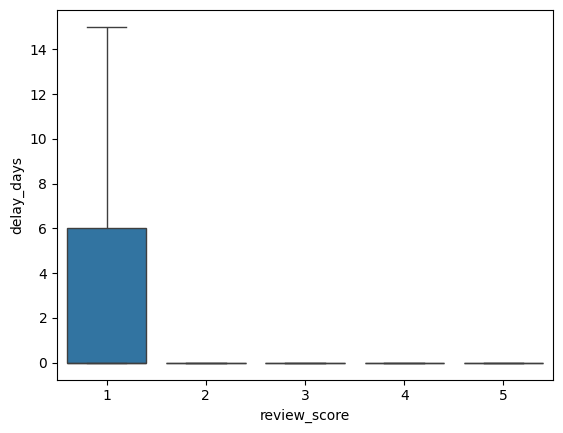

In [54]:
sns.boxplot(
    x="review_score",
    y="delay_days",
    data=df_analysis,
    showfliers=False
)

<Axes: xlabel='review_score', ylabel='delivery_days'>

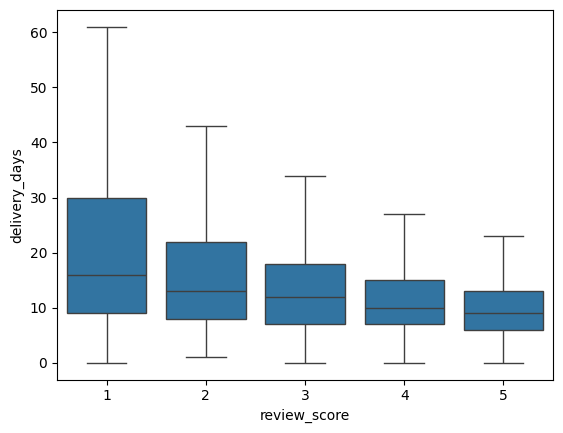

In [55]:
sns.boxplot(
    x="review_score",
    y="delivery_days",
    data=df_analysis,
    showfliers=False
)

<Axes: xlabel='review_score', ylabel='total_freight'>

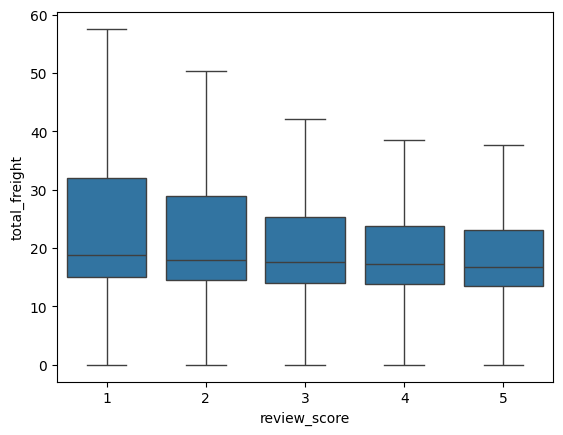

In [56]:
sns.boxplot(
    x="review_score",
    y="total_freight",
    data=df_analysis,
    showfliers=False
)

<Axes: xlabel='delivery_days', ylabel='Count'>

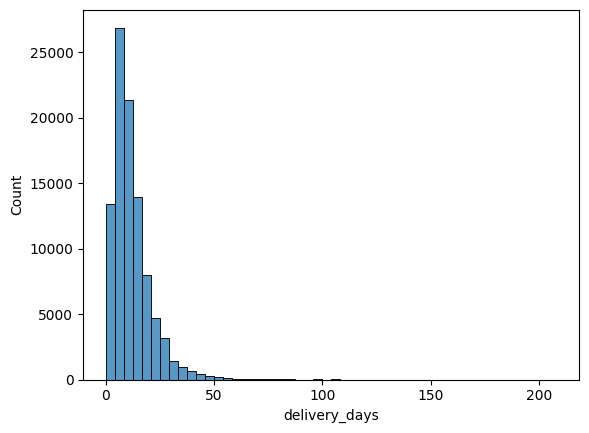

In [57]:
sns.histplot(
    df_analysis["delivery_days"],
    bins=50
)

<Axes: xlabel='delay_days', ylabel='Count'>

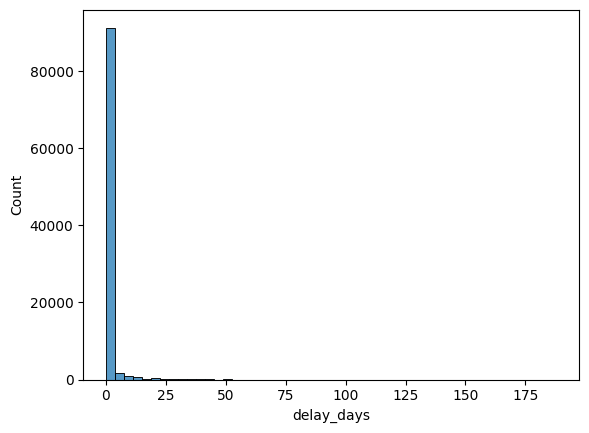

In [58]:
sns.histplot(
    df_analysis["delay_days"],
    bins=50
)